In this notebook, we build a **route-based customer care chatbot** using LangGraph.

The system:

- Uses a router agent to classify the user query  
- Routes the query to one of three agents: technical, sales, or general  
- Uses a tool-based agent to generate a direct response  

### 1. Install Dependencies

Install the required libraries using **uv** or **pip**.

`uv add langchain langchain-openai langgraph python-dotenv`


### 2. Import Required Libraries

We import:

- `dotenv` -> to load environment variables  
- `os` -> to access environment variables  
- `typing` -> to define state types and routing labels  
- LangChain utilities -> to create LLM agents and tools  
- LangGraph utilities -> to build a routing workflow graph  

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os
from typing import Annotated, TypedDict, Literal

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# Load API key
openai_key = os.getenv("OPENAI_API_KEY")


### 3. Tool 1: Technical Support Tool

This tool handles common technical issues such as:

- App crash  
- Login issue  
- App freezing  

The tool returns a predefined response based on keyword matching.


In [2]:
class TechnicalSupportTool:
    __name__ = "TechnicalSupportTool"

    def __call__(self, query: str) -> str:
        responses = {
            "app crash": "Please try reinstalling the app and update your OS.",
            "login issue": "Try resetting your password using the 'Forgot Password' link.",
            "freezing": "Clear the app cache and restart your device.",
        }
        for keyword, response in responses.items():
            if keyword in query.lower():
                return response
        return "Please provide more details about the technical issue."

@tool
def technical_support_tool(query: str) -> str:
    """Handle technical issues"""
    tool = TechnicalSupportTool()
    return tool(query)


### 4. Tool 2: Sales Support Tool

This tool handles pricing and sales-related queries such as:

- Cost  
- Discount  
- Pricing plans  

The tool returns a predefined response based on keyword matching.


In [3]:
class SalesTool:
    __name__ = "SalesTool"

    def __call__(self, query: str) -> str:
        responses = {
            "cost": "Our premium plan costs $49.99/month with 24/7 support.",
            "discount": "Yes! We are offering 20% off for new users this week.",
            "pricing": "We have Basic, Pro, and Premium plans starting at $9.99/month.",
        }
        for keyword, response in responses.items():
            if keyword in query.lower():
                return response
        return "Let me connect you to a sales representative for more details."

@tool
def sales_tool(query: str) -> str:
    """Handle pricing and sales questions"""
    tool = SalesTool()
    return tool(query)


### 5. Tool 3: General Inquiry Tool

This tool handles general customer questions such as:

- Business hours  
- Location  
- Contact information  

The tool returns a predefined response based on keyword matching.


In [4]:
class GeneralInfoTool:
    __name__ = "GeneralInfoTool"

    def __call__(self, query: str) -> str:
        responses = {
            "hours": "We are open from 9 AM to 6 PM, Monday to Friday.",
            "location": "Our headquarters are located in San Francisco, CA.",
            "contact": "You can contact us at support@example.com or call 1800-123-456.",
        }
        for keyword, response in responses.items():
            if keyword in query.lower():
                return response
        return "Can you clarify your question? I'm here to help."

@tool
def general_info_tool(query: str) -> str:
    """Answer general questions like hours, location, and contact info"""
    tool = GeneralInfoTool()
    return tool(query)


### 6. Define State

LangGraph uses a shared state to pass information between nodes.

Here, the state contains:

- `messages` -> conversation history used by the router and agents  
- `next_agent` -> routing decision stored by the router  


In [6]:
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    next_agent: str


### 7. Agent 1: Technical Support Agent

This agent:

- Handles technical queries  
- Always uses the `technical_support_tool`  
- Returns a short direct response  


In [7]:
tech_llm = ChatOpenAI(model="gpt-4o", api_key=openai_key).bind_tools([technical_support_tool])

def tech_agent(state: State) -> State:
    system_prompt = """Tech Support Agent
Role: Handle technical issues
Instructions: Use the technical support tool to answer user queries. Keep responses helpful and simple. Provide them direct answer using the tool, do not ask further questions. Provide short answer in less than two lines."""
    
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = tech_llm.invoke(messages)
    return {"messages": [response]}


### 8. Agent 2: Sales Agent

This agent:

- Handles pricing and sales queries  
- Always uses the `sales_tool`  
- Returns a short direct response 


In [8]:
sales_llm = ChatOpenAI(model="gpt-4o", api_key=openai_key).bind_tools([sales_tool])

def sales_agent(state: State) -> State:
    system_prompt = """Sales Agent
Role: Handle pricing and sales questions
Instructions: Use the sales tool to answer pricing and discount-related questions. Provide them direct answer using the tool, do not ask further questions. Provide short answer in less than two lines."""
    
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = sales_llm.invoke(messages)
    return {"messages": [response]}


### 9. Agent 3: General Inquiry Agent

This agent:

- Handles general inquiries  
- Always uses the `general_info_tool`  
- Returns a short direct response  


In [9]:
general_llm = ChatOpenAI(model="gpt-4o", api_key=openai_key).bind_tools([general_info_tool])

def general_agent(state: State) -> State:
    system_prompt = """General Inquiry Agent
Role: Answer general questions like hours, location, and contact info
Instructions: Use the general info tool to help with common inquiries. Provide them direct answer using the tool, do not ask further questions. Provide short answer in less than two lines."""
    
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = general_llm.invoke(messages)
    return {"messages": [response]}


### 10. Router Agent

The router agent decides which specialist agent should handle the query.

It outputs only one word:

- `tech` -> technical issues  
- `sales` -> pricing and sales questions  
- `general` -> general inquiries  


In [10]:
router_llm = ChatOpenAI(model="gpt-4o", api_key=openai_key)

def router_team(state: State) -> State:
    system_prompt = """Customer Care Chatbot Agent (Router)
Instructions: Route the query to the correct agent based on whether it's technical, sales, or general.

Analyze the user's query and decide:
- If it's about technical issues (app crash, login, freezing, bugs) → respond with ONLY: "tech"
- If it's about pricing, costs, discounts, plans, sales → respond with ONLY: "sales"
- If it's about hours, location, contact info, general questions → respond with ONLY: "general"

Respond with ONLY ONE WORD: tech, sales, or general"""
    
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = router_llm.invoke(messages)
    
    decision = response.content.strip().lower()
    print(f"Router Decision: {decision}")
    
    return {"next_agent": decision}


### 11. Route to the Correct Agent

Based on the router decision, we route to:

- `tech_agent`  
- `sales_agent`  
- `general_agent`  


In [11]:
# Route to the appropriate agent
def route_query(state: State) -> Literal["tech_agent", "sales_agent", "general_agent"]:
    next_agent = state.get("next_agent", "general")
    
    if "tech" in next_agent:
        return "tech_agent"
    elif "sales" in next_agent:
        return "sales_agent"
    else:
        return "general_agent"


### 12. Build the Workflow Graph

We build a LangGraph workflow where:

- The router runs first  
- The router routes the query to the right agent  
- Each agent calls its tool node  
- The graph ends after tool execution  


In [12]:
builder = StateGraph(State)

# Add nodes
builder.add_node("router", router_team)
builder.add_node("tech_agent", tech_agent)
builder.add_node("sales_agent", sales_agent)
builder.add_node("general_agent", general_agent)
builder.add_node("tech_tools", ToolNode([technical_support_tool]))
builder.add_node("sales_tools", ToolNode([sales_tool]))
builder.add_node("general_tools", ToolNode([general_info_tool]))

# Define edges
builder.add_edge(START, "router")

# Route from router to appropriate agent
builder.add_conditional_edges("router", route_query)

# Each agent ALWAYS uses tools (no conditional)
builder.add_edge("tech_agent", "tech_tools")
builder.add_edge("tech_tools", END)

builder.add_edge("sales_agent", "sales_tools")
builder.add_edge("sales_tools", END)

builder.add_edge("general_agent", "general_tools")
builder.add_edge("general_tools", END)

# Compile the graph
graph = builder.compile()


### 13. Visualize the Graph

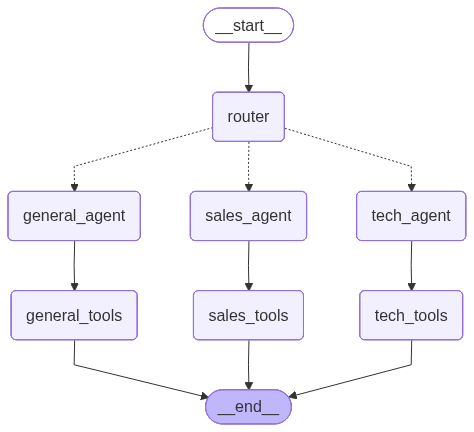

In [13]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


### 14. Run Test Cases

We test the router using sample queries.


In [15]:
# ------------------ Test Cases ------------------
#print("\n--- TEST 1: TECHNICAL ---")
state = graph.invoke({
     "messages": [HumanMessage(content="My app keeps freezing whenever I try to open settings.")],
     "next_agent": ""
 })

# print("\n--- TEST 2: SALES ---")
#state = graph.invoke({
#     "messages": [HumanMessage(content="Do you have any ongoing discounts on the premium plan?")],
#     "next_agent": ""
# })

#print("\n--- TEST 3: GENERAL INFO ---")
#state = graph.invoke({
#    "messages": [HumanMessage(content="What are your business hours on weekdays?")],
#    "next_agent": ""
#})
print(state["messages"][-1].content)

Router Decision: tech
Clear the app cache and restart your device.
